# Hamiltonian Flow Matching - K-Particle Spring Chain

This notebook transports Gaussian endpoint distributions on the configuration
space of `k_particles` particles in 2D,

$$q=(q_1,\ldots,q_k)\in (R^2)^k,$$

under a zero-rest-length nearest-neighbor spring-chain potential

$$U(q)=\frac{\kappa}{2}\sum_{i=1}^{k-1}\lVert q_{i+1}-q_i\rVert^2.$$

It follows the same forward/backward `MeanStdBVPGaussianPath` structure as
`2_particles_spring.ipynb`, but keeps the number of particles configurable.

In [13]:
import sys, os
sys.path.insert(0, os.path.abspath('../../../'))


import math
import torch
if torch.cuda.is_available() and torch.cuda.device_count() > 2:
    device = torch.device('cuda:2')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

import numpy as np
import matplotlib.pyplot as plt
from torch.distributions import MultivariateNormal
from torchdyn.core import NeuralODE

from torchcfm.hamiltonian import MeanStdBVPGaussianPath, flow_matching_loss
from torchcfm.optimal_transport import OTPlanSampler
from torchcfm.models.models_v2 import MLP
from torchcfm.utils import torch_wrapper




def to_numpy(x):
    return x.detach().cpu().numpy()

In [14]:
torch.manual_seed(42)
np.random.seed(42)

# Configuration-space dimension: k particles in 2D.
k_particles = 5
n_particles = k_particles
particle_dim = 2
dim = n_particles * particle_dim

# Endpoint geometry: particles start on a line segment and the target is a 45-degree center rotation.
chain_length = 10.0
source_positions = torch.stack(
    [
        torch.linspace(0.0, chain_length, n_particles, device=device),
        torch.zeros(n_particles, device=device),
    ],
    dim=1,
)
rotation_angle = math.pi / 4.0
rotation_cos = math.cos(rotation_angle)
rotation_sin = math.sin(rotation_angle)
rotation_matrix = torch.tensor(
    [[rotation_cos, -rotation_sin], [rotation_sin, rotation_cos]],
    device=device,
    dtype=source_positions.dtype,
)
chain_center = source_positions.mean(dim=0, keepdim=True)
target_positions = (source_positions - chain_center) @ rotation_matrix.T + chain_center
source_mean = source_positions.reshape(-1)
target_mean = target_positions.reshape(-1)

# Training controls. Increase n_dataset/n_iters for production runs.
batch_size = 64
n_dataset = 64
n_epochs = 10
n_iters = 1000
n_warmup_iters = 10_000
batch_size_warmup = 1024
lr = 5e-4
sigma_path = 0.01
n_steps = 150
tol = 1e-5
quadrature_order = 2  # Product Gauss-Hermite nodes scale as quadrature_order ** dim.

kappa = 1.0
covariance = 0.1
gaussian_std = torch.tensor(math.sqrt(covariance), device=device)
solve_t_span = torch.linspace(0, 1, n_steps + 1, device=device)
eval_batch = 1000

print(f'device: {device}')
print(f'k_particles: {k_particles}, dim: {dim}')
print(f'quadrature nodes per mesh point: {quadrature_order ** dim}')
print(f'source mean: {source_mean.tolist()}')
print(f'target mean: {target_mean.tolist()}')

device: cuda:2
k_particles: 5, dim: 10
quadrature nodes per mesh point: 1024
source mean: [0.0, 0.0, 2.5, 0.0, 5.0, 0.0, 7.5, 0.0, 10.0, 0.0]
target mean: [1.4644660949707031, -3.535533905029297, 3.2322330474853516, -1.7677669525146484, 5.0, 0.0, 6.767766952514648, 1.7677669525146484, 8.535533905029297, 3.535533905029297]


## Spring-Chain Potential

For the chain potential, the Hamiltonian mean equation is

$$\ddot q=-\kappa Lq,$$

where `L` is the graph Laplacian of the path graph on `k_particles` nodes. The
local potential class exposes `gradient` and `linear_gradient`, which are the
interfaces used by `MeanStdBVPGaussianPath`.

In [15]:
def chain_laplacian(n, *, device=None, dtype=None):
    lap = torch.zeros((n, n), device=device, dtype=dtype)
    if n <= 1:
        return lap
    idx = torch.arange(n - 1, device=device)
    lap[idx, idx] += 1.0
    lap[idx + 1, idx + 1] += 1.0
    lap[idx, idx + 1] -= 1.0
    lap[idx + 1, idx] -= 1.0
    return lap


class KParticleSpringPotential:
    def __init__(self, n_particles, particle_dim=2, kappa=1.0):
        self.n_particles = int(n_particles)
        self.particle_dim = int(particle_dim)
        self.kappa = float(kappa)

    def _reshape(self, q):
        return q.reshape(q.shape[0], self.n_particles, self.particle_dim)

    def energy(self, q):
        q_particles = self._reshape(q)
        diffs = q_particles[:, 1:] - q_particles[:, :-1]
        return 0.5 * self.kappa * (diffs ** 2).sum(dim=(1, 2))

    def gradient(self, q):
        original_shape = q.shape
        q_particles = self._reshape(q)
        grad = torch.zeros_like(q_particles)
        if self.n_particles > 1:
            diffs = q_particles[:, 1:] - q_particles[:, :-1]
            grad[:, :-1] -= self.kappa * diffs
            grad[:, 1:] += self.kappa * diffs
        return grad.reshape(original_shape)

    def linear_gradient(self, q):
        return self.gradient(q)

    def force(self, q):
        return -self.gradient(q)


potential = KParticleSpringPotential(n_particles=n_particles, particle_dim=particle_dim, kappa=kappa)

q_test = source_mean.reshape(1, -1)
print(f'U(source_mean) = {potential.energy(q_test).item():.4f}')
print(f'force(source_mean) = {potential.force(q_test).reshape(n_particles, particle_dim)}')

U(source_mean) = 12.5000
force(source_mean) = tensor([[ 2.5000, -0.0000],
        [-0.0000, -0.0000],
        [-0.0000, -0.0000],
        [-0.0000, -0.0000],
        [-2.5000, -0.0000]], device='cuda:2')


## Endpoint Distributions

Both endpoint distributions live on configuration space, not phase space:

$$\rho_0 = N(\mu_0, 0.5 I_{2k}),\quad
  \rho_1 = N(\mu_1, 0.5 I_{2k}).$$

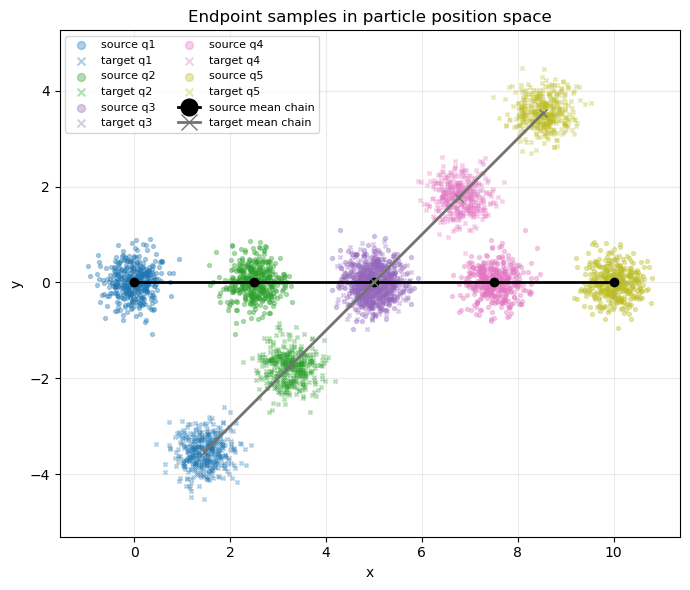

In [16]:
source_dist = MultivariateNormal(
    source_mean, covariance * torch.eye(dim, device=device)
)
target_dist = MultivariateNormal(
    target_mean, covariance * torch.eye(dim, device=device)
)


def sample_source(n):
    return source_dist.sample((n,)).to(device)


def sample_target(n):
    return target_dist.sample((n,)).to(device)


def as_particles(q):
    return q.reshape(*q.shape[:-1], n_particles, particle_dim)


def particle_colors():
    cmap = plt.cm.tab10 if n_particles <= 10 else plt.cm.hsv
    return cmap(np.linspace(0, 1, n_particles, endpoint=False))


def maybe_label(text, idx):
    return text if n_particles <= 8 else None


def plot_particle_samples(x0, x1, title, n_show=400):
    x0p = to_numpy(as_particles(x0[:n_show]))
    x1p = to_numpy(as_particles(x1[:n_show]))
    src = to_numpy(as_particles(source_mean.reshape(1, -1)))[0]
    tgt = to_numpy(as_particles(target_mean.reshape(1, -1)))[0]
    colors = particle_colors()

    plt.figure(figsize=(7, 6))
    for i, color in enumerate(colors):
        plt.scatter(x0p[:, i, 0], x0p[:, i, 1], s=8, color=color, alpha=0.35, label=maybe_label(f'source q{i + 1}', i))
        plt.scatter(x1p[:, i, 0], x1p[:, i, 1], s=8, color=color, alpha=0.35, marker='x', label=maybe_label(f'target q{i + 1}', i))
    plt.plot(src[:, 0], src[:, 1], color='black', linewidth=2.0, marker='o', label='source mean chain')
    plt.plot(tgt[:, 0], tgt[:, 1], color='0.45', linewidth=2.0, marker='x', label='target mean chain')

    plt.axis('equal')
    plt.grid(alpha=0.25)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(title)
    if n_particles <= 8:
        plt.legend(markerscale=2, ncols=2, fontsize=8)
    else:
        plt.legend(markerscale=2, fontsize=8)
    plt.tight_layout()
    plt.show()


x0_vis = sample_source(500)
x1_vis = sample_target(500)
plot_particle_samples(x0_vis, x1_vis, 'Endpoint samples in particle position space')

## Closed-Form Mean Boundary-Value Check

Because the spring-chain system is linear, the deterministic BVP can be solved by
diagonalizing the chain Laplacian. The zero eigenvalue gives the center-of-mass
linear mode; positive eigenvalues give sinusoidal modes.

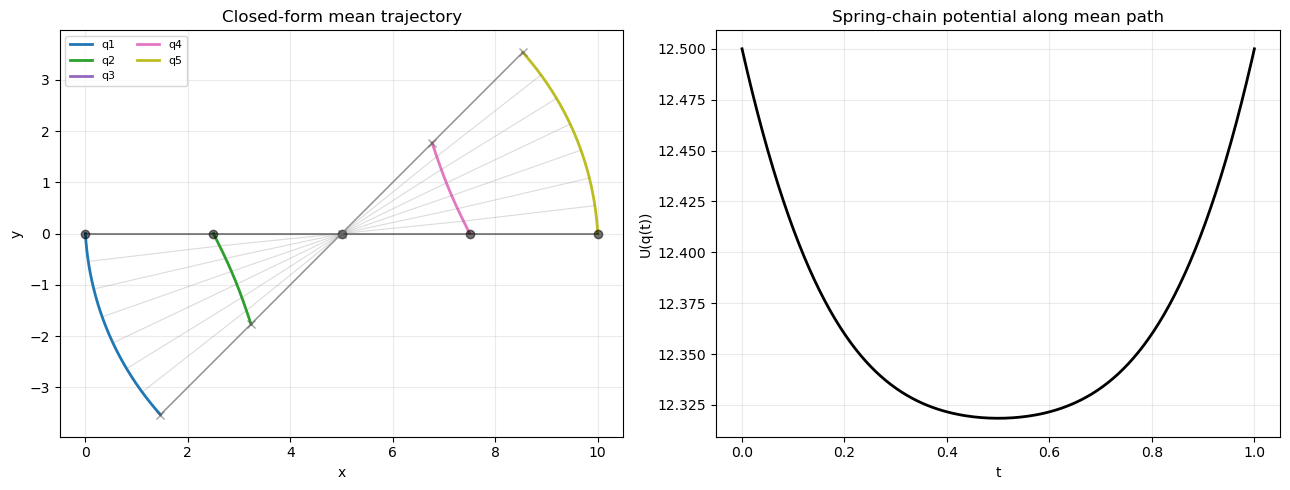

In [17]:
def closed_form_chain_spring_path_batch(t_grid, q0_batch, q1_batch, kappa=1.0):
    q0_batch = q0_batch.to(device=device)
    q1_batch = q1_batch.to(device=q0_batch.device, dtype=q0_batch.dtype)
    q0p = as_particles(q0_batch)
    q1p = as_particles(q1_batch)
    t = torch.as_tensor(t_grid, dtype=q0_batch.dtype, device=q0_batch.device).reshape(-1, 1, 1, 1)

    lap = chain_laplacian(n_particles, device=q0_batch.device, dtype=q0_batch.dtype)
    eigvals, eigvecs = torch.linalg.eigh(lap)
    omega = torch.sqrt((kappa * eigvals).clamp_min(0.0))
    sin_omega = torch.sin(omega)
    singular = (omega > 1e-8) & (sin_omega.abs() < 1e-6)
    if torch.any(singular):
        raise ValueError('A positive spring mode has sin(omega) near zero; this BVP is singular for the chosen kappa/time horizon.')

    y0 = torch.einsum('km,bkd->bmd', eigvecs, q0p)
    y1 = torch.einsum('km,bkd->bmd', eigvecs, q1p)
    omega_v = omega.reshape(1, 1, n_particles, 1)
    positive = (omega > 1e-8).reshape(1, 1, n_particles, 1)

    linear = (1.0 - t) * y0.unsqueeze(0) + t * y1.unsqueeze(0)
    oscillatory = (
        torch.cos(omega_v * t) * y0.unsqueeze(0)
        + torch.sin(omega_v * t) / sin_omega.reshape(1, 1, n_particles, 1).clamp_min(1e-12)
        * (y1.unsqueeze(0) - torch.cos(omega_v) * y0.unsqueeze(0))
    )
    y_t = torch.where(positive, oscillatory, linear)
    q_t = torch.einsum('km,tbmd->tbkd', eigvecs, y_t)
    return q_t.reshape(t.shape[0], q0_batch.shape[0], dim)


def closed_form_chain_spring_mean(t, q0=source_mean, q1=target_mean, kappa=1.0):
    return closed_form_chain_spring_path_batch(
        t,
        q0.reshape(1, -1),
        q1.reshape(1, -1),
        kappa=kappa,
    )[:, 0]


t_plot = torch.linspace(0, 1, 200, device=device)
mean_path = closed_form_chain_spring_mean(t_plot, kappa=kappa)
mean_particles = to_numpy(as_particles(mean_path))
mean_energy = to_numpy(potential.energy(mean_path))
colors = particle_colors()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for i, color in enumerate(colors):
    axes[0].plot(mean_particles[:, i, 0], mean_particles[:, i, 1], color=color, linewidth=2.0, label=maybe_label(f'q{i + 1}', i))
axes[0].plot(mean_particles[0, :, 0], mean_particles[0, :, 1], color='black', alpha=0.55, linewidth=1.2, marker='o')
axes[0].plot(mean_particles[-1, :, 0], mean_particles[-1, :, 1], color='0.35', alpha=0.55, linewidth=1.2, marker='x')
for idx in np.linspace(0, len(mean_particles) - 1, 8).astype(int):
    axes[0].plot(mean_particles[idx, :, 0], mean_particles[idx, :, 1], color='0.45', alpha=0.25, linewidth=0.8)
axes[0].axis('equal')
axes[0].grid(alpha=0.25)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('Closed-form mean trajectory')
if n_particles <= 8:
    axes[0].legend(fontsize=8, ncols=2)

axes[1].plot(to_numpy(t_plot), mean_energy, color='black', linewidth=2.0)
axes[1].set_xlabel('t')
axes[1].set_ylabel('U(q(t))')
axes[1].set_title('Spring-chain potential along mean path')
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

## Model and BVP Helpers

`MeanStdBVPGaussianPath` stores states `[mu, mu_dot, sigma, sigma_dot]`. The helper
functions mirror the forward/backward spring notebook, with plotting generalized
to `k_particles`.

In [18]:
ot_sampler = OTPlanSampler(method='exact')

fwd_model = MLP(dim + 1, out_dim=dim, w=128).to(device)
bwd_model = MLP(dim + 1, out_dim=dim, w=128).to(device)
fwd_optimizer = torch.optim.Adam(fwd_model.parameters(), lr=lr)
bwd_optimizer = torch.optim.Adam(bwd_model.parameters(), lr=lr)

fwd_losses = []
bwd_losses = []


def make_node(model):
    return NeuralODE(torch_wrapper(model), sensitivity='adjoint', solver='euler')


def trajectory_to_guesses(traj, reverse=True):
    # traj has shape (time, batch, dim). The BVP path expects (batch, time, dim).
    if reverse:
        traj = torch.flip(traj, dims=(0,))
    traj = traj.detach()
    if traj.shape[0] != n_steps + 1:
        raise ValueError(f'Expected {n_steps + 1} trajectory time points, got {traj.shape[0]}.')

    dt = 1.0 / n_steps
    mu_dot = torch.empty_like(traj)
    mu_dot[0] = (traj[1] - traj[0]) / dt
    mu_dot[-1] = (traj[-1] - traj[-2]) / dt
    mu_dot[1:-1] = (traj[2:] - traj[:-2]) / (2.0 * dt)

    mu_guess = to_numpy(traj.permute(1, 0, 2).contiguous())
    mu_dot_guess = to_numpy(mu_dot.permute(1, 0, 2).contiguous())
    return mu_guess, mu_dot_guess


def make_path(mu_guess=None, mu_dot_guess=None):
    sigma_guess = None
    sigma_dot_guess = None
    if mu_guess is not None:
        n_pairs = mu_guess.shape[0]
        sigma_guess = np.full((n_pairs, n_steps + 1), sigma_path, dtype=float)
        sigma_dot_guess = np.zeros((n_pairs, n_steps + 1), dtype=float)

    return MeanStdBVPGaussianPath(
        potential,
        sigma=sigma_path,
        n_steps=n_steps,
        tol=tol,
        quadrature_order=quadrature_order,
        mu_guess=mu_guess,
        mu_dot_guess=mu_dot_guess,
        sigma_guess=sigma_guess,
        sigma_dot_guess=sigma_dot_guess,
    )


def solve_bvp_paths(x0, x1, mu_guess=None, mu_dot_guess=None, label='path'):
    path = make_path(mu_guess, mu_dot_guess)
    print(f'Solving {x0.shape[0]} {label} mean/std BVPs...')
    states = path.batch_solve(x0, x1)
    keep = path.success_mask.to(device=x0.device)
    x0_keep = x0[keep]
    x1_keep = x1[keep]
    n_failed = int((~keep).sum().item())
    print(f'{label}: kept {x0_keep.shape[0]} / {keep.numel()} BVPs; failed {n_failed}; states: {states.shape}')
    if n_failed:
        preview = list(path.failure_messages.items())[:5]
        print(f'{label}: first failures: {preview}')
    return path, x0_keep, x1_keep, states


def train_on_cached_paths(model, optimizer, path, x0, x1, n_steps_train, label, log_every=200):
    model.train()
    step_losses = []
    n_pairs = x0.shape[0]
    if n_pairs == 0:
        raise RuntimeError(f'{label}: no successful BVP pairs to train on.')

    x0 = x0.to(device)
    x1 = x1.to(device)
    for step in range(n_steps_train):
        optimizer.zero_grad()

        idx = torch.randint(0, n_pairs, (batch_size,), device=device)
        x0_b = x0[idx]
        x1_b = x1[idx]
        t = torch.rand((batch_size, 1), device=device, dtype=x0_b.dtype)
        epsilon = torch.randn_like(x0_b)

        xt = path.sample_xt(x0_b, x1_b, t, epsilon)
        ut = path.compute_ut(x0_b, x1_b, t, xt)
        vt = model(torch.cat([xt, t], dim=-1))
        loss = flow_matching_loss(vt, ut)

        loss.backward()
        optimizer.step()
        step_losses.append(loss.item())

        if step % log_every == 0 or step == n_steps_train - 1:
            print(f'{label} step {step:5d}: loss = {loss.item():.5f}')
    return step_losses


def train_on_ot_pairs(model, optimizer, x0, x1, n_steps_train, label, log_every=200):
    model.train()
    step_losses = []
    n_pairs = x0.shape[0]
    if n_pairs == 0:
        raise RuntimeError(f'{label}: no OT pairs to train on.')

    x0 = x0.to(device)
    x1 = x1.to(device)
    for step in range(n_steps_train):
        optimizer.zero_grad()

        idx = torch.randint(0, n_pairs, (batch_size,), device=device)
        x0_b = x0[idx]
        x1_b = x1[idx]
        t = torch.rand((batch_size, 1), device=device, dtype=x0_b.dtype)

        xt = (1.0 - t) * x0_b + t * x1_b
        ut = x1_b - x0_b
        vt = model(torch.cat([xt, t], dim=-1))
        loss = flow_matching_loss(vt, ut)

        loss.backward()
        optimizer.step()
        step_losses.append(loss.item())

        if step % log_every == 0 or step == n_steps_train - 1:
            print(f'{label} step {step:5d}: loss = {loss.item():.5f}')
    return step_losses

## Initial Mean/Std BVP Dataset

The initial cached dataset is useful for sanity checks and visualizing the
Gaussian mean and standard-deviation schedules before alternating training.

In [19]:
mean_path_solver = make_path()
mean_states = mean_path_solver.batch_solve(
    source_mean.reshape(1, -1),
    target_mean.reshape(1, -1),
)
mean_bvp_mu = mean_states[0, :, :dim].to(device)
mean_closed_mu = closed_form_chain_spring_mean(mean_path_solver.t_grid.to(device), kappa=kappa)
max_mean_error = (mean_bvp_mu - mean_closed_mu).abs().max().item()
print(f'max |BVP mean path - closed form|: {max_mean_error:.3e}')
print(f'min sigma on mean BVP: {mean_states[0, :, 2 * dim].min().item():.3e}')

x0_all = sample_source(n_dataset)
x1_all = sample_target(n_dataset)
x0_coupled, x1_coupled = ot_sampler.sample_plan(x0_all, x1_all)
path, x0_coupled, x1_coupled, states = solve_bvp_paths(x0_coupled, x1_coupled, label='initial')
n_dataset = x0_coupled.shape[0]

max |BVP mean path - closed form|: 2.861e-06
min sigma on mean BVP: 1.000e-02
Solving 64 initial mean/std BVPs...
initial: kept 64 / 64 BVPs; failed 0; states: torch.Size([64, 151, 22])


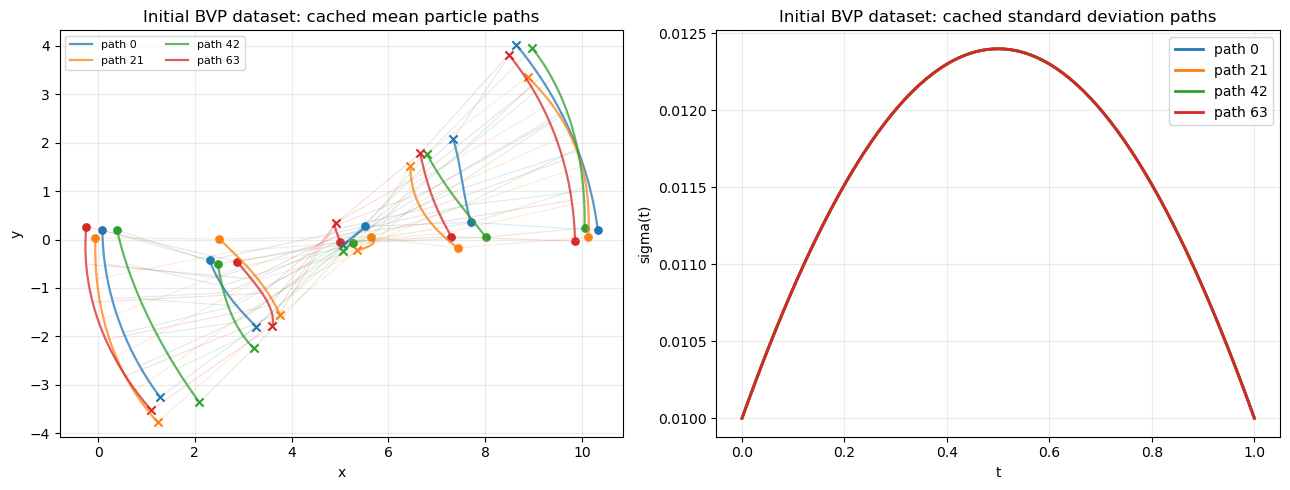

In [20]:
def plot_cached_mean_std_paths(path, states, title, n_mean_std_show=4):
    if states is None or states.shape[0] == 0:
        print(f'{title}: no cached states to plot.')
        return

    n_mean_std_show = min(n_mean_std_show, states.shape[0])
    plot_idx = torch.linspace(0, states.shape[0] - 1, n_mean_std_show).long()
    t_state = to_numpy(path.t_grid[:states.shape[1]])
    mean_paths = to_numpy(as_particles(states[plot_idx, :, :dim]))
    sigma_paths = to_numpy(states[plot_idx, :, 2 * dim])
    colors = plt.cm.tab10(np.arange(n_mean_std_show))

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    spring_idx = np.linspace(0, mean_paths.shape[1] - 1, 6).astype(int)
    for j, idx in enumerate(plot_idx.tolist()):
        color = colors[j]
        for pidx in range(n_particles):
            axes[0].plot(
                mean_paths[j, :, pidx, 0], mean_paths[j, :, pidx, 1],
                color=color, alpha=0.75, linewidth=1.6,
                label=f'path {idx}' if pidx == 0 else None,
            )
        axes[0].scatter(mean_paths[j, 0, :, 0], mean_paths[j, 0, :, 1], s=28, color=color, marker='o')
        axes[0].scatter(mean_paths[j, -1, :, 0], mean_paths[j, -1, :, 1], s=35, color=color, marker='x')
        for sidx in spring_idx:
            axes[0].plot(
                mean_paths[j, sidx, :, 0], mean_paths[j, sidx, :, 1],
                color=color, alpha=0.16, linewidth=0.8
            )

    axes[0].axis('equal')
    axes[0].grid(alpha=0.25)
    axes[0].set_xlabel('x')
    axes[0].set_ylabel('y')
    axes[0].set_title(f'{title}: cached mean particle paths')
    axes[0].legend(fontsize=8, ncols=2)

    for j, idx in enumerate(plot_idx.tolist()):
        axes[1].plot(t_state, sigma_paths[j], color=colors[j], linewidth=2.0, label=f'path {idx}')
    axes[1].set_xlabel('t')
    axes[1].set_ylabel('sigma(t)')
    axes[1].set_title(f'{title}: cached standard deviation paths')
    axes[1].grid(alpha=0.25)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


plot_cached_mean_std_paths(path, states, 'Initial BVP dataset')

## Warmup on Zero-Potential OT Pairs

In [21]:
x0_warm = sample_source(batch_size_warmup)
x1_warm = sample_target(batch_size_warmup)
x0_warm, x1_warm = ot_sampler.sample_plan(x0_warm, x1_warm)

fwd_losses.extend(
    train_on_ot_pairs(
        fwd_model, fwd_optimizer, x0_warm, x1_warm,
        n_warmup_iters, label='warmup fwd'
    )
)
bwd_losses.extend(
    train_on_ot_pairs(
        bwd_model, bwd_optimizer, x1_warm, x0_warm,
        n_warmup_iters, label='warmup bwd'
    )
)

warmup fwd step     0: loss = 4.03481
warmup fwd step   200: loss = 0.04570
warmup fwd step   400: loss = 0.04251
warmup fwd step   600: loss = 0.04142
warmup fwd step   800: loss = 0.04096
warmup fwd step  1000: loss = 0.04136
warmup fwd step  1200: loss = 0.04353
warmup fwd step  1400: loss = 0.04353
warmup fwd step  1600: loss = 0.03676
warmup fwd step  1800: loss = 0.04666
warmup fwd step  2000: loss = 0.03821
warmup fwd step  2200: loss = 0.04324
warmup fwd step  2400: loss = 0.04567
warmup fwd step  2600: loss = 0.04279
warmup fwd step  2800: loss = 0.03974
warmup fwd step  3000: loss = 0.03926
warmup fwd step  3200: loss = 0.03980
warmup fwd step  3400: loss = 0.03918
warmup fwd step  3600: loss = 0.04145
warmup fwd step  3800: loss = 0.03904
warmup fwd step  4000: loss = 0.04218
warmup fwd step  4200: loss = 0.04493
warmup fwd step  4400: loss = 0.04021
warmup fwd step  4600: loss = 0.04434
warmup fwd step  4800: loss = 0.03852
warmup fwd step  5000: loss = 0.04569
warmup fwd s

## Alternating Forward/Backward Training

In [22]:
last_fwd_path = None
last_bwd_path = None
last_fwd_states = None
last_bwd_states = None
last_fwd_x0, last_fwd_x1 = None, None
last_bwd_x0, last_bwd_x1 = None, None

for epoch in range(n_epochs):
    if epoch % 2 == 0:
        # Train fwd using couplings induced by the current bwd NODE.
        y_target = sample_target(n_dataset)
        bwd_model.eval()
        bwd_node = make_node(bwd_model)
        with torch.no_grad():
            bwd_traj = bwd_node.trajectory(y_target, t_span=solve_t_span)
        generated_source = bwd_traj[-1].detach()
        mu_guess, mu_dot_guess = trajectory_to_guesses(bwd_traj, reverse=True)

        last_fwd_path, last_fwd_x0, last_fwd_x1, last_fwd_states = solve_bvp_paths(
            generated_source, y_target, mu_guess, mu_dot_guess, label=f'epoch {epoch} fwd'
        )
        fwd_losses.extend(
            train_on_cached_paths(
                fwd_model, fwd_optimizer, last_fwd_path, last_fwd_x0, last_fwd_x1,
                n_iters, label=f'epoch {epoch} fwd'
            )
        )
    else:
        # Train bwd using couplings induced by the current fwd NODE.
        x_source = sample_source(n_dataset)
        fwd_model.eval()
        fwd_node = make_node(fwd_model)
        with torch.no_grad():
            fwd_traj = fwd_node.trajectory(x_source, t_span=solve_t_span)
        generated_target = fwd_traj[-1].detach()
        mu_guess, mu_dot_guess = trajectory_to_guesses(fwd_traj, reverse=True)

        last_bwd_path, last_bwd_x0, last_bwd_x1, last_bwd_states = solve_bvp_paths(
            generated_target, x_source, mu_guess, mu_dot_guess, label=f'epoch {epoch} bwd'
        )
        bwd_losses.extend(
            train_on_cached_paths(
                bwd_model, bwd_optimizer, last_bwd_path, last_bwd_x0, last_bwd_x1,
                n_iters, label=f'epoch {epoch} bwd'
            )
        )

Solving 64 epoch 0 fwd mean/std BVPs...
epoch 0 fwd: kept 64 / 64 BVPs; failed 0; states: torch.Size([64, 151, 22])
epoch 0 fwd step     0: loss = 0.23045
epoch 0 fwd step   200: loss = 0.00895
epoch 0 fwd step   400: loss = 0.00491
epoch 0 fwd step   600: loss = 0.00281
epoch 0 fwd step   800: loss = 0.00294
epoch 0 fwd step   999: loss = 0.00198
Solving 64 epoch 1 bwd mean/std BVPs...
epoch 1 bwd: kept 64 / 64 BVPs; failed 0; states: torch.Size([64, 151, 22])
epoch 1 bwd step     0: loss = 0.22165
epoch 1 bwd step   200: loss = 0.00819
epoch 1 bwd step   400: loss = 0.00492
epoch 1 bwd step   600: loss = 0.00322
epoch 1 bwd step   800: loss = 0.00281
epoch 1 bwd step   999: loss = 0.00168
Solving 64 epoch 2 fwd mean/std BVPs...
epoch 2 fwd: kept 64 / 64 BVPs; failed 0; states: torch.Size([64, 151, 22])
epoch 2 fwd step     0: loss = 0.01187
epoch 2 fwd step   200: loss = 0.00227
epoch 2 fwd step   400: loss = 0.00192
epoch 2 fwd step   600: loss = 0.00137
epoch 2 fwd step   800: loss

## Training Losses

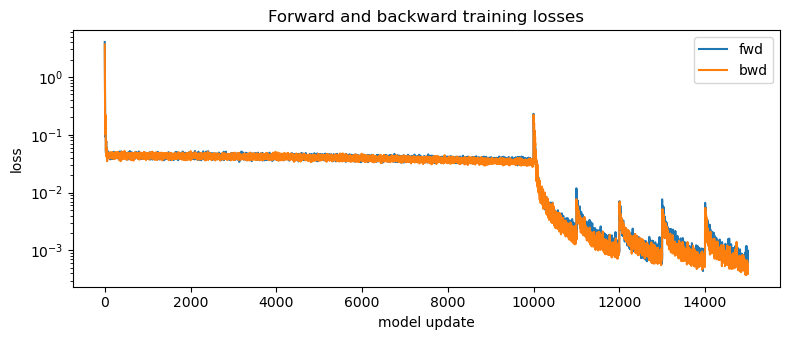

In [23]:
plt.figure(figsize=(8, 3.5))
plt.semilogy(fwd_losses, label='fwd')
plt.semilogy(bwd_losses, label='bwd')
plt.xlabel('model update')
plt.ylabel('loss')
plt.title('Forward and backward training losses')
plt.legend()
plt.tight_layout()
plt.show()

## Last Solved BVP Datasets

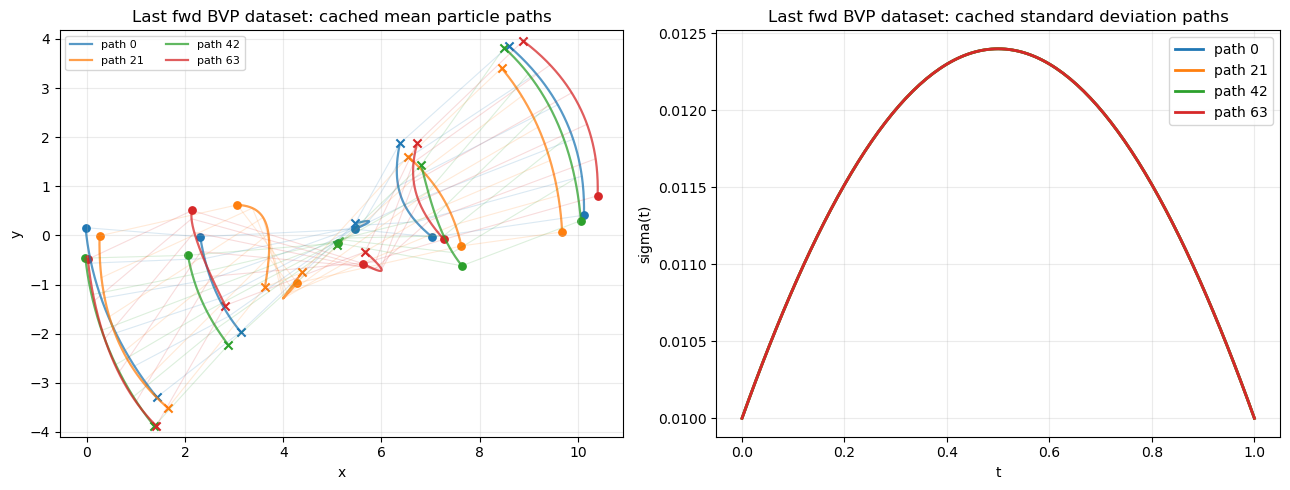

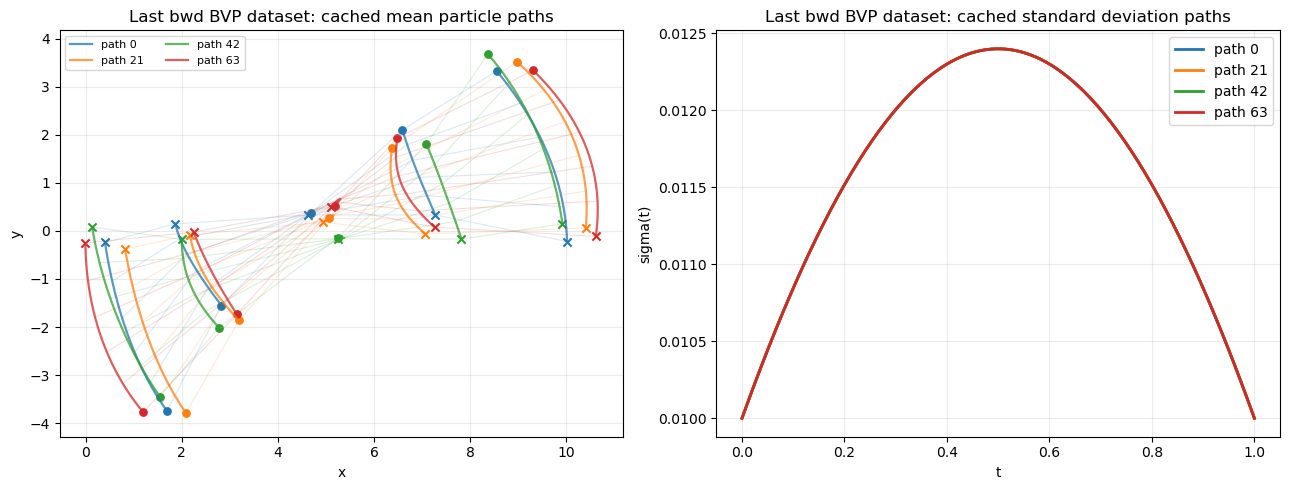

In [24]:
if last_fwd_states is not None:
    plot_cached_mean_std_paths(last_fwd_path, last_fwd_states, 'Last fwd BVP dataset')
if last_bwd_states is not None:
    plot_cached_mean_std_paths(last_bwd_path, last_bwd_states, 'Last bwd BVP dataset')

## Evaluation

In [25]:
fwd_model.eval()
bwd_model.eval()
fwd_node = make_node(fwd_model)
bwd_node = make_node(bwd_model)
eval_t_span = torch.linspace(0, 1, 100, device=device)

with torch.no_grad():
    fwd_traj = fwd_node.trajectory(sample_source(eval_batch), t_span=eval_t_span)
    bwd_traj = bwd_node.trajectory(sample_target(eval_batch), t_span=eval_t_span)

fwd_traj_plot = to_numpy(fwd_traj)
bwd_traj_plot = to_numpy(bwd_traj)
fwd_target_ref = to_numpy(sample_target(eval_batch))
bwd_source_ref = to_numpy(sample_source(eval_batch))

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


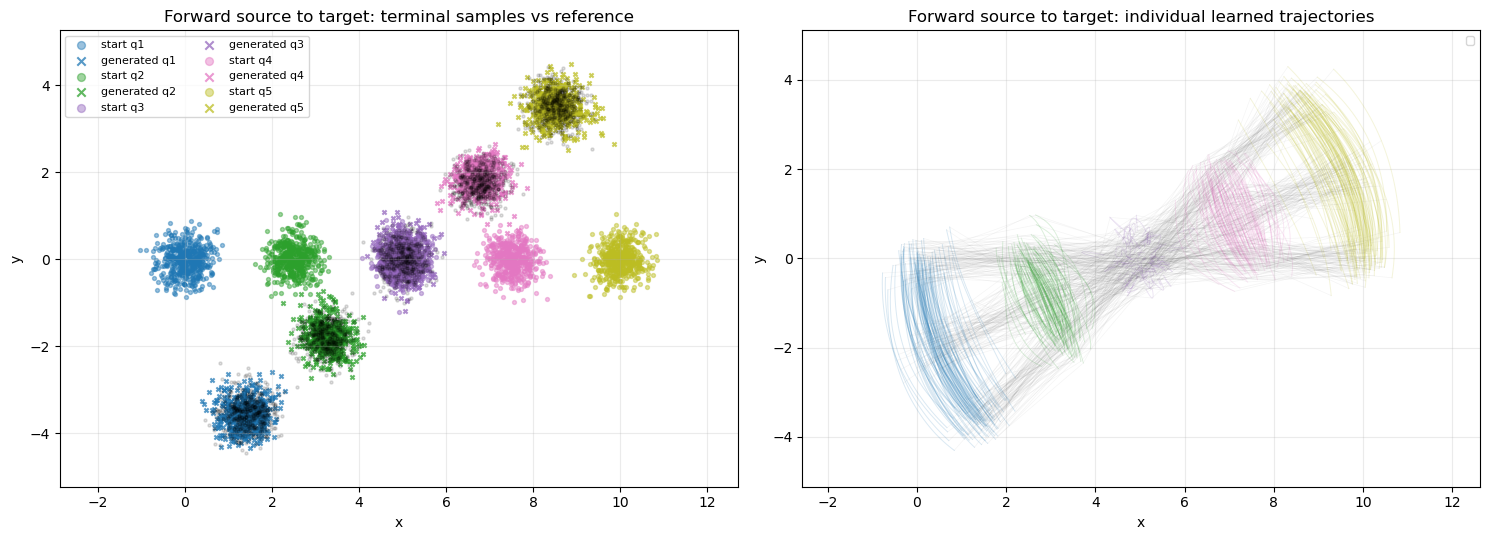

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


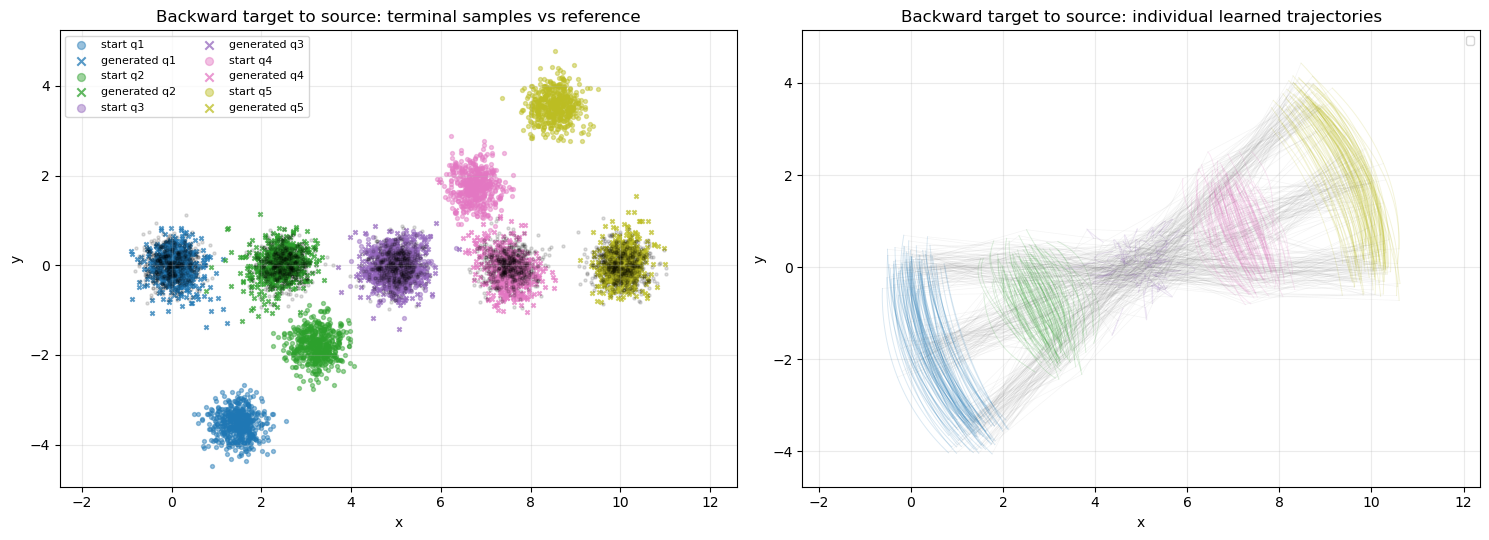

In [26]:
def plot_learned_particle_trajectories(traj_plot, reference, title, n_show=500, n_lines=100):
    n_show = min(n_show, traj_plot.shape[1])
    n_lines = min(n_lines, traj_plot.shape[1])
    traj_particles = traj_plot.reshape(traj_plot.shape[0], traj_plot.shape[1], n_particles, particle_dim)
    ref_particles = reference.reshape(reference.shape[0], n_particles, particle_dim)
    colors = particle_colors()

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

    for pidx, color in enumerate(colors):
        axes[0].scatter(traj_particles[0, :n_show, pidx, 0], traj_particles[0, :n_show, pidx, 1], s=8, color=color, alpha=0.45, label=maybe_label(f'start q{pidx + 1}', pidx))
        axes[0].scatter(traj_particles[-1, :n_show, pidx, 0], traj_particles[-1, :n_show, pidx, 1], s=9, color=color, marker='x', alpha=0.75, label=maybe_label(f'generated q{pidx + 1}', pidx))
        axes[0].scatter(ref_particles[:n_show, pidx, 0], ref_particles[:n_show, pidx, 1], s=5, color='black', alpha=0.12)

    axes[0].set_title(f'{title}: terminal samples vs reference')

    spring_idx = [0, traj_particles.shape[0] // 2, traj_particles.shape[0] - 1]
    for i in range(n_lines):
        for pidx, color in enumerate(colors):
            axes[1].plot(traj_particles[:, i, pidx, 0], traj_particles[:, i, pidx, 1], color=color, alpha=0.16, linewidth=0.7)
        for sidx in spring_idx:
            axes[1].plot(traj_particles[sidx, i, :, 0], traj_particles[sidx, i, :, 1], color='0.35', alpha=0.06, linewidth=0.5)
    axes[1].set_title(f'{title}: individual learned trajectories')

    for ax in axes:
        ax.axis('equal')
        ax.grid(alpha=0.25)
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        if n_particles <= 8:
            ax.legend(markerscale=2, fontsize=8, ncols=2)

    plt.tight_layout()
    plt.show()


plot_learned_particle_trajectories(fwd_traj_plot, fwd_target_ref, 'Forward source to target')
plot_learned_particle_trajectories(bwd_traj_plot, bwd_source_ref, 'Backward target to source')

In [27]:
def print_terminal_summary(name, generated_np, reference_mean, target_covariance):
    generated = torch.as_tensor(generated_np[-1], device=device, dtype=reference_mean.dtype)
    generated_mean = generated.mean(dim=0)
    generated_cov_diag = generated.var(dim=0, unbiased=True)

    print(f'{name} terminal mean:', generated_mean.tolist())
    print(f'{name} reference mean:', reference_mean.tolist())
    print(f'{name} covariance diagonal:', generated_cov_diag.tolist())
    print(f'{name} reference covariance diagonal:', [target_covariance] * dim)
    print(f'{name} mean error norm:', torch.linalg.norm(generated_mean - reference_mean).item())


print_terminal_summary('Forward', fwd_traj_plot, target_mean, covariance)
print_terminal_summary('Backward', bwd_traj_plot, source_mean, covariance)

Forward terminal mean: [1.3751904964447021, -3.560938596725464, 3.2840447425842285, -1.7952803373336792, 4.997918128967285, 0.053771693259477615, 6.772892951965332, 1.8819053173065186, 8.518634796142578, 3.510279417037964]
Forward reference mean: [1.4644660949707031, -3.535533905029297, 3.2322330474853516, -1.7677669525146484, 5.0, 0.0, 6.767766952514648, 1.7677669525146484, 8.535533905029297, 3.535533905029297]
Forward covariance diagonal: [0.11222196370363235, 0.10482820868492126, 0.10326358675956726, 0.11038435250520706, 0.09298132359981537, 0.12794645130634308, 0.10808521509170532, 0.10072135180234909, 0.1425439566373825, 0.1196083351969719]
Forward reference covariance diagonal: [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1]
Forward mean error norm: 0.17008794844150543
Backward terminal mean: [0.08120309561491013, -0.0031594596803188324, 2.414881944656372, 0.05044921115040779, 4.968508243560791, -0.0630306750535965, 7.513339519500732, -0.10808003693819046, 10.033546447753906, 

## Forward NODE vs Closed-Form Spring BVP

Sample fresh source configurations, transport them with the learned forward NODE,
then solve the analytic spring-chain boundary-value problem between each source
sample and its generated terminal sample. This compares the learned trajectory
against the exact deterministic Hamiltonian path for the same endpoints.

In [28]:
fwd_model.eval()
fwd_node = make_node(fwd_model)

comparison_batch = eval_batch
eval_x0 = sample_source(comparison_batch)
with torch.no_grad():
    learned_traj = fwd_node.trajectory(eval_x0, t_span=eval_t_span)

generated_x1 = learned_traj[-1].detach()
closed_form_traj = closed_form_chain_spring_path_batch(eval_t_span, eval_x0, generated_x1, kappa=kappa)

trajectory_rmse = torch.sqrt(torch.mean((learned_traj - closed_form_traj) ** 2)).item()
per_time_rmse = torch.sqrt(torch.mean((learned_traj - closed_form_traj) ** 2, dim=(1, 2)))
closed_form_start_error = torch.linalg.norm(closed_form_traj[0] - eval_x0, dim=-1).mean().item()
closed_form_end_error = torch.linalg.norm(closed_form_traj[-1] - generated_x1, dim=-1).mean().item()

print(f'Forward NODE vs closed-form BVP trajectory RMSE: {trajectory_rmse:.6e}')
print(f'Closed-form start endpoint mean error: {closed_form_start_error:.6e}')
print(f'Closed-form terminal endpoint mean error: {closed_form_end_error:.6e}')

Forward NODE vs closed-form BVP trajectory RMSE: 1.275738e-02
Closed-form start endpoint mean error: 2.597368e-06
Closed-form terminal endpoint mean error: 2.786744e-06


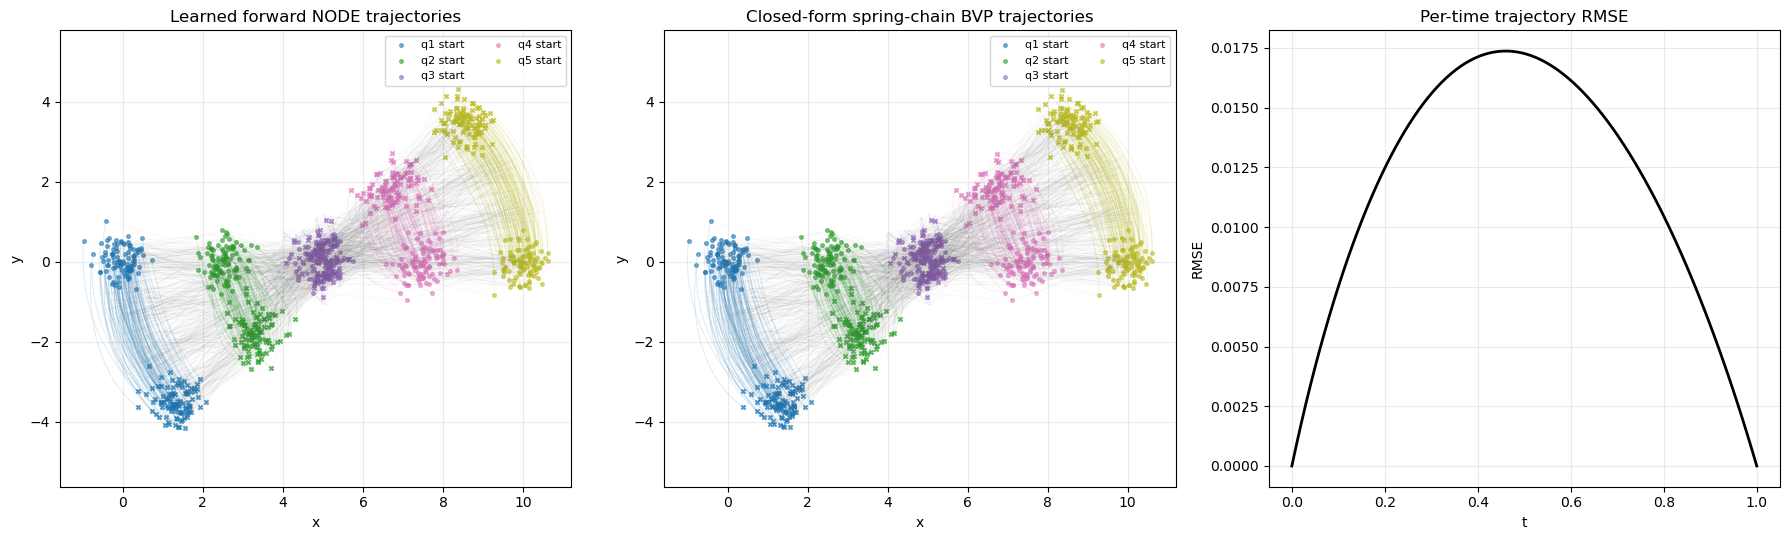

In [29]:
n_compare_lines = min(100, comparison_batch)
learned_particles = to_numpy(as_particles(learned_traj[:, :n_compare_lines]))
closed_particles = to_numpy(as_particles(closed_form_traj[:, :n_compare_lines]))
time_rmse = to_numpy(per_time_rmse)
t_eval_plot = to_numpy(eval_t_span)
colors = particle_colors()
spring_idx = np.linspace(0, learned_particles.shape[0] - 1, 4).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for i in range(n_compare_lines):
    for pidx, color in enumerate(colors):
        axes[0].plot(learned_particles[:, i, pidx, 0], learned_particles[:, i, pidx, 1], color=color, alpha=0.14, linewidth=0.7)
        axes[1].plot(closed_particles[:, i, pidx, 0], closed_particles[:, i, pidx, 1], color=color, alpha=0.14, linewidth=0.7)
    for sidx in spring_idx:
        axes[0].plot(learned_particles[sidx, i, :, 0], learned_particles[sidx, i, :, 1], color='0.35', alpha=0.05, linewidth=0.5)
        axes[1].plot(closed_particles[sidx, i, :, 0], closed_particles[sidx, i, :, 1], color='0.35', alpha=0.05, linewidth=0.5)

for pidx, color in enumerate(colors):
    axes[0].scatter(learned_particles[0, :, pidx, 0], learned_particles[0, :, pidx, 1], s=7, color=color, alpha=0.55, label=maybe_label(f'q{pidx + 1} start', pidx))
    axes[0].scatter(learned_particles[-1, :, pidx, 0], learned_particles[-1, :, pidx, 1], s=9, color=color, marker='x', alpha=0.75)
    axes[1].scatter(closed_particles[0, :, pidx, 0], closed_particles[0, :, pidx, 1], s=7, color=color, alpha=0.55, label=maybe_label(f'q{pidx + 1} start', pidx))
    axes[1].scatter(closed_particles[-1, :, pidx, 0], closed_particles[-1, :, pidx, 1], s=9, color=color, marker='x', alpha=0.75)

axes[0].set_title('Learned forward NODE trajectories')
axes[1].set_title('Closed-form spring-chain BVP trajectories')

axes[2].plot(t_eval_plot, time_rmse, color='black', linewidth=2.0)
axes[2].set_xlabel('t')
axes[2].set_ylabel('RMSE')
axes[2].set_title('Per-time trajectory RMSE')
axes[2].grid(alpha=0.25)

for ax in axes[:2]:
    ax.axis('equal')
    ax.grid(alpha=0.25)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    if n_particles <= 8:
        ax.legend(fontsize=8, ncols=2)

plt.tight_layout()
plt.show()